# Gaussian smoothing

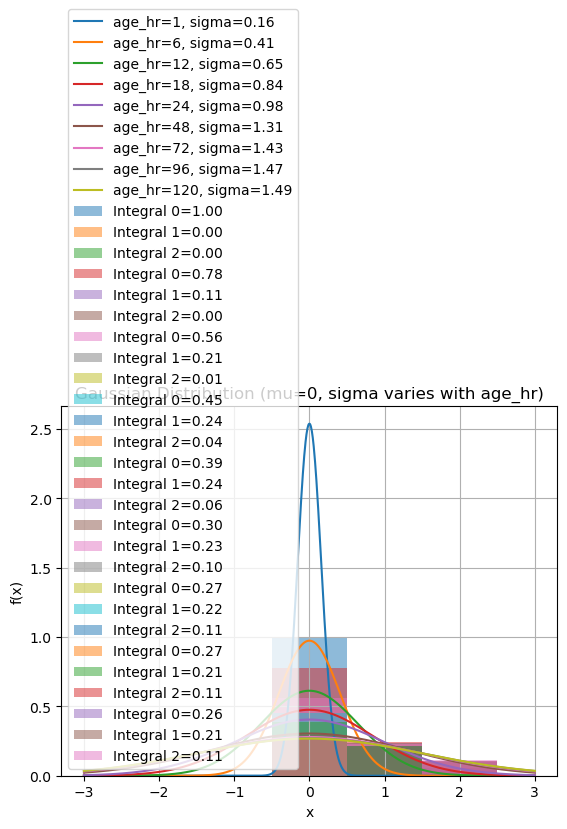

In [9]:
# plot a gaussian distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
def gaussian(x, mu, age_hr, kernel_size=3):
    min_sigma = 0.1
    # autoselecte a max_sigma depending on kernel_size
    max_sigma = kernel_size / 2.0
    # print(f"Using max_sigma={max_sigma} for kernel_size={kernel_size}")
    sigma = min_sigma + (max_sigma - min_sigma) * (1 - np.exp(age_hr / -24.0))
    return sigma, (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
def gaussian_cdf(mu, sigma, x):
    return 0.5 * (1 + erf((x - mu) / (sigma * np.sqrt(2))))

def gaussian_integral(x, sigma):
    return gaussian_cdf(0, sigma, x+0.5) - gaussian_cdf(0, sigma, x-0.5)

kernel_size = 3

x = np.linspace(-1*kernel_size, kernel_size, 1000)
mu = 0


for age_hr in [1, 6, 12, 18, 24, 48, 72, 96, 120]:
    sigma, y = gaussian(x, mu, age_hr, kernel_size)
    plt.plot(x, y, label=f'age_hr={age_hr}, sigma={sigma:.2f}')
    # plot also the integral under the curve between -.5 and .5, and so on as barcharts
    # the bars should be centered at the middle of the interval, and the width should be the size of the interval
    for interval in range(kernel_size):
        integral = gaussian_integral(interval, sigma)
        plt.bar(interval, integral, width=1, alpha=0.5, label=f'Integral {interval}={integral:.2f}')


plt.title('Gaussian Distribution (mu=0, sigma varies with age_hr)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.show()

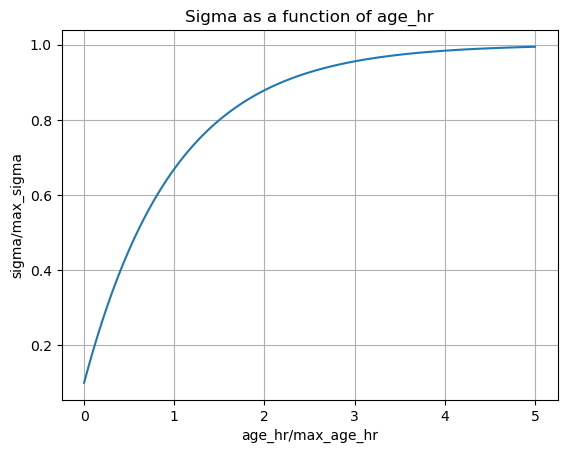

In [55]:
# plot a curve for the age_hr to sigma formula

age_hr_values = np.linspace(0, 5, 100)
# a typical formula for sigma as a function of age_hr
# for gaussian atmospheric transport models
min_sigma = 0.1
sigma_values = min_sigma + (1 - min_sigma) * (1-np.exp(age_hr_values / -1))
# why should sigma increase faster with age_hr

plt.plot(age_hr_values, sigma_values)
plt.title('Sigma as a function of age_hr')
plt.xlabel('age_hr/max_age_hr')
plt.ylabel('sigma/max_sigma')
plt.grid()
plt.show()


## Smoothing vs diffusion

SNAP horizontal diffusion is l = a * u ^ b, with u = horizontal wind-speed, and a = 0.5, b = 0.875 (a = 0.25 above ABL).
Valid at 15min.

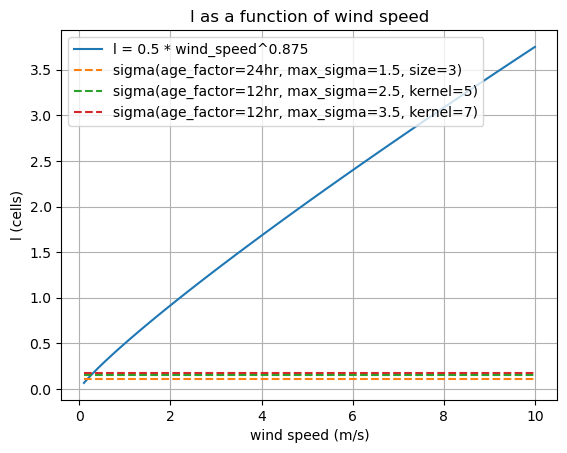

In [21]:
# plot l depending on wind-speed 0.1m/s to 20m/s
wind_speeds = np.linspace(0.1, 10, 100)
a = 0.5
b = 0.875
# a typical formula for l as a function of wind speed
l = a * wind_speeds**b
sigma24_3 = 0.1 + (1.5 - 0.1) * (1-np.exp(-1. * 0.25 / 24))
sigma12_5 = 0.1 + (2.5 - 0.1) * (1-np.exp(-1. * 0.25 / 12))
sigma12_7 = 0.1 + (3.5 - 0.1) * (1-np.exp(-1. * 0.25 / 12))
plt.plot(wind_speeds, l, label=f'l = {a} * wind_speed^{b}')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma24_3), label=f'sigma(age_factor=24hr, max_sigma=1.5, size=3)', linestyle='--')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma12_5), label=f'sigma(age_factor=12hr, max_sigma=2.5, kernel=5)', linestyle='--')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma12_7), label=f'sigma(age_factor=12hr, max_sigma=3.5, kernel=7)', linestyle='--')
plt.title('l as a function of wind speed')
plt.xlabel('wind speed (m/s)')
plt.ylabel('l (cells)')
plt.legend()
plt.grid()
plt.show()